In [2]:
import pandas as pd
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import shap

c:\Users\local_user\anaconda3\envs\EnergyPrices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [3]:
# calculate smape
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))


In [4]:
all_data_set = pd.read_csv("processed_data\Processed_data.csv", index_col=0)
all_data_set
# Feature lags in 15-min steps
STATE_LAGS = [1, 4, 8, 24, 96, 192, 672]   # 15m, 1h, 2h, 6h, 1d, 2d, 1w
STATE_ROLL_WINS = [24, 96, 672]            # rolling windows on past y (6h, 1d, 1w)

# Feature columns
STATE_FEATURES = (
    ["last_y"]
    + [f"lag_{L}_t0" for L in STATE_LAGS]
    + ["ramp_1h_t0", "ramp_6h_t0", "ramp_1d_t0"]
    + [f"roll_mean_{w}_t0" for w in STATE_ROLL_WINS]
    + [f"roll_std_{w}_t0" for w in STATE_ROLL_WINS]
)

HORIZON_FEATURES = [
    "h", "q_in_hour_target", "qod_target", "hod_target", "dow_target", "month_target", "is_weekend_target",
    "load_fc_target", "load_ramp_1h_target", "load_ramp_6h_target",
    "load_day_mean", "load_day_max", "load_day_min",
]

FEATURE_COLS = STATE_FEATURES + HORIZON_FEATURES

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\local_user\AppData\Local\Temp\ipykernel_4460\2176525123.py:1: SyntaxWarning: invalid escape sequence '\P'
  all_data_set = pd.read_csv("processed_data\Processed_data.csv", index_col=0)


In [5]:
def get_best_params(
    ds: pd.DataFrame,   
    train_days_pool: np.ndarray,
    val_days: np.ndarray,
    n_trials: int
):
    
    ds_train_pool = ds[ds["day"].isin(train_days_pool)].copy()
    ds_val_pool = ds[ds["day"].isin(val_days)].copy()


    def objective(trial: optuna.trial.Trial):

        preds = []
        trues = []

        synth_weight = trial.suggest_float("synth_weight", 0.05, 0.8, log=True)
        retrain_every = trial.suggest_int("retrain_every", 1, 10)

        # --- All other single-stage models ---
        for i, D in enumerate(val_days):
            train_slice = ds_train_pool[ds_train_pool["day"] < D].copy()
            day_rows = ds_val_pool[ds_val_pool["day"] == D].copy()
            if train_slice.empty or day_rows.empty:
                continue

            w = np.where(train_slice["is_synthetic"].values == 1, synth_weight, 1.0).astype(float)

            if  i % retrain_every == 0:
                # Need a fresh model each retrain for sklearn pipelines

                model = lgb.LGBMRegressor(
                    objective="regression",
                    n_estimators=trial.suggest_int("lgb_n_estimators", 400, 2500),
                    learning_rate=trial.suggest_float("lgb_lr", 0.01, 0.08, log=True),
                    num_leaves=trial.suggest_int("lgb_num_leaves", 16, 256, log=True),
                    min_child_samples=trial.suggest_int("lgb_min_child_samples", 10, 200),
                    subsample=trial.suggest_float("lgb_subsample", 0.6, 1.0),
                    colsample_bytree=trial.suggest_float("lgb_colsample", 0.6, 1.0),
                    reg_alpha=trial.suggest_float("lgb_reg_alpha", 1e-8, 10.0, log=True),
                    reg_lambda=trial.suggest_float("lgb_reg_lambda", 1e-8, 10.0, log=True),
                    random_state=42,
                    n_jobs=-1,
                    verbose=0
                )


                if hasattr(model, "fit"):
                    try:
                        model.fit(train_slice[FEATURE_COLS], train_slice["y_target"], sample_weight=w)
                    except TypeError:
                        model.fit(train_slice[FEATURE_COLS], train_slice["y_target"])
                else:
                    raise RuntimeError("Model has no fit().")
                fitted = model

            y_hat = fitted.predict(day_rows[FEATURE_COLS])
            preds.append(y_hat)
            trues.append(day_rows["y_target"].values)

        if not preds:
            return float("inf")
        
        y_true = np.concatenate(trues)
        y_hat = np.concatenate(preds)

        mae = mean_absolute_error(y_true, y_hat)
        return mae
    
    study = optuna.create_study(direction="minimize", study_name="HUPX_test")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("Best overall value:", study.best_value)
    print("Best overall params:", study.best_params)
    return study


In [ ]:
FINAL_TEST_DAYS = 30
real_rows = all_data_set[(all_data_set["is_observed"] == 1) & (all_data_set["is_synthetic"] == 0)]
real_days = np.array(sorted(real_rows["day"].unique()))

all_days = np.array(sorted(all_data_set["day"].unique()))
final_test_days = all_days[-FINAL_TEST_DAYS:]
tune_days = all_days[:-FINAL_TEST_DAYS]

# Use the last part of tune_days as Optuna validation window (e.g., 21 days)
OPTUNA_VAL_DAYS = 21
optuna_val_days = tune_days[-OPTUNA_VAL_DAYS:]
optuna_train_days_pool = tune_days[:-OPTUNA_VAL_DAYS]
print("Optuna train pool:", optuna_train_days_pool[0], "→", optuna_train_days_pool[-1], len(optuna_train_days_pool))
print("Optuna val days  :", optuna_val_days[0], "→", optuna_val_days[-1], len(optuna_val_days))
print("Final test days  :", final_test_days[0], "→", final_test_days[-1], len(final_test_days))



study = get_best_params(
    ds=all_data_set,
    train_days_pool=optuna_train_days_pool,
    val_days=optuna_val_days,
    n_trials=300
)

[I 2026-03-04 22:38:31,727] A new study created in memory with name: HUPX_test


Optuna train pool: 2024-01-16 00:00:00+01:00 → 2025-12-31 00:00:00+01:00 716
Optuna val days  : 2026-01-01 00:00:00+01:00 → 2026-01-21 00:00:00+01:00 21
Final test days  : 2026-01-22 00:00:00+01:00 → 2026-02-24 00:00:00+01:00 30


Best trial: 0. Best value: 32.4932:  10%|█         | 1/10 [01:37<14:36, 97.38s/it]

[I 2026-03-04 22:40:09,109] Trial 0 finished with value: 32.49321650209526 and parameters: {'synth_weight': 0.050234101508177705, 'retrain_every': 2, 'lgb_n_estimators': 1321, 'lgb_lr': 0.019017605122387003, 'lgb_num_leaves': 63, 'lgb_min_child_samples': 176, 'lgb_subsample': 0.6672628181317188, 'lgb_colsample': 0.7433330587365738, 'lgb_reg_alpha': 2.0453151369355125e-08, 'lgb_reg_lambda': 1.4437347941364471}. Best is trial 0 with value: 32.49321650209526.


Best trial: 0. Best value: 32.4932:  20%|██        | 2/10 [02:24<09:01, 67.65s/it]

...

[I 2026-03-04 22:50:33,000] Trial 7 finished with value: 33.71179807062492 and parameters: {'synth_weight': 0.6195540622797383, 'retrain_every': 5, 'lgb_n_estimators': 1491, 'lgb_lr': 0.07549732443080441, 'lgb_num_leaves': 81, 'lgb_min_child_samples': 163, 'lgb_subsample': 0.7935076776314625, 'lgb_colsample': 0.6774862297813766, 'lgb_reg_alpha': 1.0534713010893506e-08, 'lgb_reg_lambda': 8.604456492960864}. Best is trial 0 with value: 32.49321650209526.


Best trial: 8. Best value: 31.884:  90%|█████████ | 9/10 [12:08<01:02, 62.85s/it] 

[I 2026-03-04 22:50:40,028] Trial 8 finished with value: 31.883978230638807 and parameters: {'synth_weight': 0.32884251386265717, 'retrain_every': 7, 'lgb_n_estimators': 452, 'lgb_lr': 0.028980822213725485, 'lgb_num_leaves': 31, 'lgb_min_child_samples': 194, 'lgb_subsample': 0.7661647333542224, 'lgb_colsample': 0.7505545149714853, 'lgb_reg_alpha': 1.7605056187687148e-06, 'lgb_reg_lambda': 7.227289950937174e-08}. Best is trial 8 with value: 31.883978230638807.


Best trial: 9. Best value: 31.4484: 100%|██████████| 10/10 [12:29<00:00, 75.00s/it]

[I 2026-03-04 22:51:01,703] Trial 9 finished with value: 31.448380029074425 and parameters: {'synth_weight': 0.05345214382020343, 'retrain_every': 8, 'lgb_n_estimators': 803, 'lgb_lr': 0.07507796829783644, 'lgb_num_leaves': 140, 'lgb_min_child_samples': 45, 'lgb_subsample': 0.6112217762601257, 'lgb_colsample': 0.7781238857105321, 'lgb_reg_alpha': 2.4940913999854513e-08, 'lgb_reg_lambda': 0.004960824379896298}. Best is trial 9 with value: 31.448380029074425.
Best overall value: 31.448380029074425
Best overall params: {'synth_weight': 0.05345214382020343, 'retrain_every': 8, 'lgb_n_estimators': 803, 'lgb_lr': 0.07507796829783644, 'lgb_num_leaves': 140, 'lgb_min_child_samples': 45, 'lgb_subsample': 0.6112217762601257, 'lgb_colsample': 0.7781238857105321, 'lgb_reg_alpha': 2.4940913999854513e-08, 'lgb_reg_lambda': 0.004960824379896298}


In [8]:
def walk_forward_predict_test(
    ds,
    best_params: dict,
    train_days_pool: np.ndarray,   # days you allow for training (e.g., tune_days)
    test_days: np.ndarray,         # final_test_days
    feature_cols,
    target_col="y_target",
    day_col="day",
    synth_col="is_synthetic",
):
    test_days = np.sort(np.array(test_days))

    ds_train_pool = ds[ds[day_col].isin(train_days_pool)].copy()
    ds_test_pool  = ds[ds[day_col].isin(test_days)].copy()

    synth_weight = best_params["synth_weight"]

    # Build LGB params from Optuna best params (drop non-LGB keys)
    lgb_params = {
        "objective": "regression",
        "n_estimators": best_params["lgb_n_estimators"],
        "learning_rate": best_params["lgb_lr"],
        "num_leaves": best_params["lgb_num_leaves"],
        "min_child_samples": best_params["lgb_min_child_samples"],
        "subsample": best_params["lgb_subsample"],
        "colsample_bytree": best_params["lgb_colsample"],
        "reg_alpha": best_params["lgb_reg_alpha"],
        "reg_lambda": best_params["lgb_reg_lambda"],
        "random_state": 42,
        "n_jobs": -1,
    }

    preds = []
    trues = []
    day_index = []
    row_index = []

    fitted = None

    retrain_every = int(best_params.get("retrain_every", 1))

    for i, D in enumerate(test_days):
        train_slice = ds_train_pool[ds_train_pool[day_col] < D].copy()
        day_rows = ds_test_pool[ds_test_pool[day_col] == D].copy()
        if train_slice.empty or day_rows.empty:
            continue

        # retrain schedule (same idea as your objective)
        if (i % retrain_every == 0) or (fitted is None):
            w = np.where(train_slice[synth_col].values == 1, synth_weight, 1.0).astype(float)

            model = lgb.LGBMRegressor(**lgb_params)
            model.fit(train_slice[feature_cols], train_slice[target_col], sample_weight=w)
            fitted = model

        y_hat = fitted.predict(day_rows[feature_cols])
        y_true = day_rows[target_col].values

        preds.append(y_hat)
        trues.append(y_true)
        day_index.append(np.full(len(day_rows), D))
        row_index.append(day_rows.index.values)

    if not preds:
        raise RuntimeError("No predictions were made on test_days. Check day filters / pools.")

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)
    days_out = np.concatenate(day_index)
    rows_out = np.concatenate(row_index)

    mae = mean_absolute_error(y_true, y_pred)

    return {
        "y_pred": y_pred,
        "y_true": y_true,
        "days": days_out,
        "row_index": rows_out,
        "mae": mae,
        "last_model": fitted,  # the last fitted model (trained for last retrain point)
        "lgb_params": lgb_params,
        "synth_weight": synth_weight,
    }

In [9]:
best_params = study.best_params

test_res = walk_forward_predict_test(
    ds=all_data_set,
    best_params=best_params,
    train_days_pool=tune_days,        # important: allow training on ALL tune_days
    test_days=final_test_days,
    feature_cols=FEATURE_COLS,
)

print("Final test MAE:", test_res["mae"])

Final test MAE: 19.276580809994233


In [10]:
print(len(test_res["days"]))

2880


In [11]:
def fit_final_model_before_test(
    ds,
    best_params: dict,
    train_days_pool: np.ndarray,
    first_test_day,
    feature_cols,
    target_col="y_target",
    day_col="day",
    synth_col="is_synthetic",
):
    ds_train_pool = ds[ds[day_col].isin(train_days_pool)].copy()
    train_slice = ds_train_pool[ds_train_pool[day_col] < first_test_day].copy()
    if train_slice.empty:
        raise RuntimeError("Training slice is empty before first_test_day.")

    synth_weight = best_params["synth_weight"]
    w = np.where(train_slice[synth_col].values == 1, synth_weight, 1.0).astype(float)

    lgb_params = {
        "objective": "regression",
        "n_estimators": best_params["lgb_n_estimators"],
        "learning_rate": best_params["lgb_lr"],
        "num_leaves": best_params["lgb_num_leaves"],
        "min_child_samples": best_params["lgb_min_child_samples"],
        "subsample": best_params["lgb_subsample"],
        "colsample_bytree": best_params["lgb_colsample"],
        "reg_alpha": best_params["lgb_reg_alpha"],
        "reg_lambda": best_params["lgb_reg_lambda"],
        "random_state": 42,
        "n_jobs": -1,
    }

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(train_slice[feature_cols], train_slice[target_col], sample_weight=w)
    return model

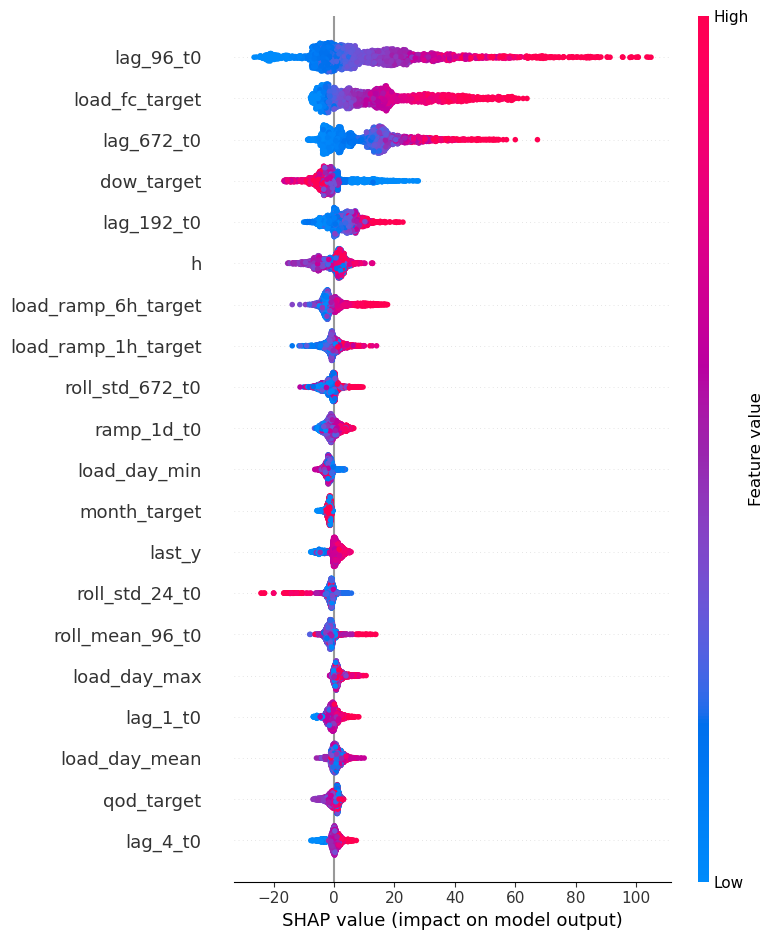

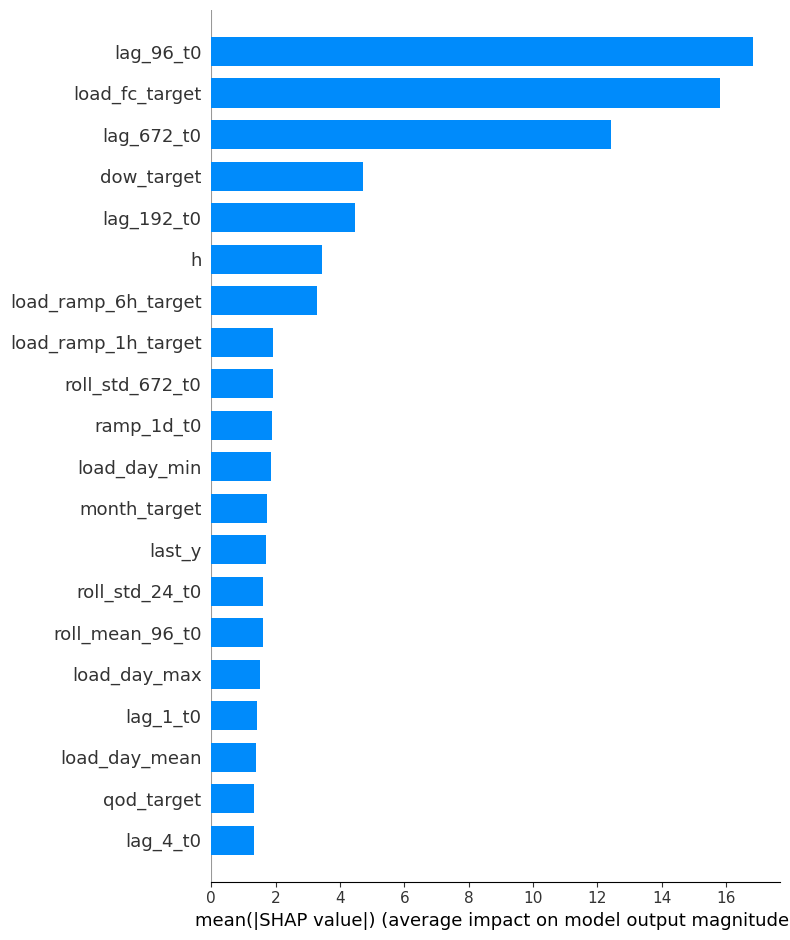

In [12]:
first_test_day = final_test_days[0]

final_model = fit_final_model_before_test(
    ds=all_data_set,
    best_params=study.best_params,
    train_days_pool=tune_days,
    first_test_day=first_test_day,
    feature_cols=FEATURE_COLS,
)

test_df = all_data_set[all_data_set["day"].isin(final_test_days)].copy()
X_test = test_df[FEATURE_COLS]


explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test)

# Bar plot (global importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

## Save the SHAP

In [13]:
explainer = shap.TreeExplainer(final_model)
sv = explainer.shap_values(X_test)
# regression / binary: sv is (n_samples, n_features)
# multiclass: sv is list of arrays
if isinstance(sv, list):
    per_class = [np.mean(np.abs(s), axis=0) for s in sv]
    mean_abs = np.mean(per_class, axis=0)
else:
    mean_abs = np.mean(np.abs(sv), axis=0)

imp = pd.Series(mean_abs, index=X_test.columns, name="mean_abs_shap")

MODEL_NAME = "LigthGBM_model"  # change per notebook
out = pd.DataFrame({"feature": imp.index, "mean_abs_shap": imp.values})
out.to_csv(f"out_shap/shap_global_{MODEL_NAME}.csv", index=False)